# OULAD Early Prediction Project  
**Student Name:** Vukosi Khoza (2605669)

**Objective:** Predict student outcome (Fail/Pass) using data available up to week 4

## 1. Imports and Setup

This section imports all required libraries and sets up the environment for the analysis.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

## 2. Data Loading

Load all OULAD dataset files and verify that they are correctly imported.

In [5]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(".")   # current notebook folder

files = {
    "studentInfo": "studentInfo.csv",
    "studentVle": "studentVle.csv",
    "vle": "vle.csv",
    "assessments": "assessments.csv",
    "studentAssessment": "studentAssessment.csv",
    "studentRegistration": "studentRegistration.csv",
    "courses": "courses.csv",
}

for name, file in files.items():
    path = DATA_DIR / file
    print(name, "exists:", path.exists(), "| path:", path)

student_info = pd.read_csv(DATA_DIR / "studentInfo.csv")
student_vle = pd.read_csv(DATA_DIR / "studentVle.csv")
vle = pd.read_csv(DATA_DIR / "vle.csv")
assessments = pd.read_csv(DATA_DIR / "assessments.csv")
student_assessment = pd.read_csv(DATA_DIR / "studentAssessment.csv")
student_registration = pd.read_csv(DATA_DIR / "studentRegistration.csv")
courses = pd.read_csv(DATA_DIR / "courses.csv")

print("Loaded successfully")

studentInfo exists: True | path: studentInfo.csv
studentVle exists: True | path: studentVle.csv
vle exists: True | path: vle.csv
assessments exists: True | path: assessments.csv
studentAssessment exists: True | path: studentAssessment.csv
studentRegistration exists: True | path: studentRegistration.csv
courses exists: True | path: courses.csv
Loaded successfully


## 3. Data Overview

Inspect dataset shapes and basic structure to understand available information.

In [6]:
print("student_info:", student_info.shape)
print("student_vle:", student_vle.shape)
print("vle:", vle.shape)
print("assessments:", assessments.shape)
print("student_assessment:", student_assessment.shape)
print("student_registration:", student_registration.shape)
print("courses:", courses.shape)

student_info: (32593, 12)
student_vle: (10655280, 6)
vle: (6364, 6)
assessments: (206, 6)
student_assessment: (173912, 5)
student_registration: (32593, 5)
courses: (22, 3)


## 4. Target Definition

Define the prediction target:
- Pass / Distinction → 1 (favourable)
- Fail / Withdrawn → 0 (at-risk)

In [7]:
# Create binary target
student_info["target"] = student_info["final_result"].map({
    "Pass": 1,
    "Distinction": 1,
    "Fail": 0,
    "Withdrawn": 0
})

# Check mapping worked
print(student_info[["final_result", "target"]].head())

# Check class distribution
print("\nClass distribution:")
print(student_info["target"].value_counts())

print("\nProportions:")
print(student_info["target"].value_counts(normalize=True))

  final_result  target
0         Pass       1
1         Pass       1
2    Withdrawn       0
3         Pass       1
4         Pass       1

Class distribution:
target
0    17208
1    15385
Name: count, dtype: int64

Proportions:
target
0    0.527966
1    0.472034
Name: proportion, dtype: float64


In [8]:
print(student_info["target"].isnull().sum())


0


## 5. Week 4 Filtering (Leakage Prevention)

To ensure a fair prediction task, only data available up to the end of week 4 (day ≤ 28) is used.

This prevents data leakage, where the model would otherwise learn from future information.

In [56]:
# Keep only interactions up to day 28
student_vle_w4 = student_vle[student_vle["date"] <= 27].copy()

print("Original VLE:", student_vle.shape)
print("Week 4 VLE:", student_vle_w4.shape)

print(student_vle_w4.columns)

Original VLE: (10655280, 6)
Week 4 VLE: (2801311, 6)
Index(['code_module', 'code_presentation', 'id_student', 'id_site', 'date',
       'sum_click'],
      dtype='object')


In [57]:
# Merge student assessments with assessment info to get dates
student_assessment_merged = student_assessment.merge(
    assessments,
    on="id_assessment",
    how="left"
)

# Keep only assessments due up to week 4
student_assessment_w4 = student_assessment_merged[
    student_assessment_merged["date"] <= 27
].copy()

print("Original assessments:", student_assessment.shape)
print("Week 4 assessments:", student_assessment_w4.shape)

Original assessments: (173912, 5)
Week 4 assessments: (22043, 10)


In [11]:
# Registration info (we don't filter here, but inspect it)
student_registration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [12]:
print(student_vle_w4["date"].max())
print(student_assessment_w4["date"].max())

28
25.0


## 6. Feature Engineering

Create meaningful features using only data available up to week 4:
- VLE activity (student engagement)
- Assessment performance (early scores)
- Student demographics

These features will be used to train prediction models.

In [23]:
vle_features = (
    student_vle_w4
    .groupby(["code_module", "code_presentation", "id_student"])
    .agg(
        total_clicks_w4=("sum_click", "sum"),
        avg_clicks_w4=("sum_click", "mean"),
        active_days_w4=("date", "nunique"),
        total_events_w4=("id_site", "count"),
        unique_sites_w4=("id_site", "nunique")
    )
    .reset_index()
)

vle_features.head()

,code_module,code_presentation,id_student,total_clicks_w4,avg_clicks_w4,active_days_w4,total_events_w4,unique_sites_w4
0,AAA,2013J,11391,401,6.683333,8,60,24
1,AAA,2013J,28400,618,3.862500,19,160,34
2,AAA,2013J,30268,281,3.697368,12,76,22
3,AAA,2013J,31604,494,3.553957,22,139,31
4,AAA,2013J,32885,567,3.754967,24,151,34


In [24]:
# Add activity type information to week-4 VLE data
student_vle_w4_activity = student_vle_w4.merge(
    vle[["id_site", "activity_type"]],
    on="id_site",
    how="left"
)

activity_features = (
    student_vle_w4_activity
    .groupby(["code_module", "code_presentation", "id_student", "activity_type"])
    ["sum_click"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

activity_features.head()

activity_type,code_module,code_presentation,id_student,dataplus,dualpane,externalquiz,forumng,glossary,homepage,htmlactivity,...,oucontent,ouelluminate,ouwiki,page,questionnaire,quiz,resource,sharedsubpage,subpage,url
0,AAA,2013J,11391,0,0,0,55,0,42,0,...,273,0,0,0,0,0,9,0,21,1
1,AAA,2013J,28400,0,0,0,209,0,132,0,...,183,0,0,0,0,0,5,0,59,30
2,AAA,2013J,30268,0,0,0,126,0,59,0,...,66,0,0,0,0,0,4,0,22,4
3,AAA,2013J,31604,0,0,0,131,1,95,0,...,188,0,0,0,0,0,10,0,52,17
4,AAA,2013J,32885,0,0,0,138,2,102,0,...,284,0,0,0,0,0,7,0,28,6


In [25]:
assessment_features = (
    student_assessment_w4
    .groupby(["code_module", "code_presentation", "id_student"])
    .agg(
        mean_score_w4=("score", "mean"),
        total_score_w4=("score", "sum"),
        assessments_done_w4=("id_assessment", "count")
    )
    .reset_index()
)

assessment_features.head()

,code_module,code_presentation,id_student,mean_score_w4,total_score_w4,assessments_done_w4
0,AAA,2013J,11391,78.0,78.0,1
1,AAA,2013J,28400,70.0,70.0,1
2,AAA,2013J,31604,72.0,72.0,1
3,AAA,2013J,32885,69.0,69.0,1
4,AAA,2013J,38053,79.0,79.0,1


In [26]:
demographic_features = student_info[[
    "code_module",
    "code_presentation",
    "id_student",
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "num_of_prev_attempts",
    "studied_credits",
    "disability",
    "target"
]].copy()

demographic_features.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,target
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,1
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,1
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,1
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,1


In [32]:
df = demographic_features.merge(
    vle_features,
    on=["code_module", "code_presentation", "id_student"],
    how="left"
)

df = df.merge(
    activity_features,
    on=["code_module", "code_presentation", "id_student"],
    how="left"
)

df = df.merge(
    assessment_features,
    on=["code_module", "code_presentation", "id_student"],
    how="left"
)

# Fill missing values safely by column type
cat_cols_df = df.select_dtypes(include=["object", "bool"]).columns
num_cols_df = df.select_dtypes(include=["int64", "float64"]).columns

df[cat_cols_df] = df[cat_cols_df].fillna("Missing")
df[num_cols_df] = df[num_cols_df].fillna(0)

df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,page,questionnaire,quiz,resource,sharedsubpage,subpage,url,mean_score_w4,total_score_w4,assessments_done_w4
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,0.0,0.0,0.0,9.0,0.0,21.0,1.0,78.0,78.0,1.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,0.0,0.0,0.0,5.0,0.0,59.0,30.0,70.0,70.0,1.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,0.0,0.0,4.0,0.0,22.0,4.0,0.0,0.0,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,0.0,0.0,0.0,10.0,0.0,52.0,17.0,72.0,72.0,1.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,0.0,0.0,0.0,7.0,0.0,28.0,6.0,69.0,69.0,1.0


In [33]:
print("Final dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Target distribution:")
print(df["target"].value_counts(normalize=True))

Final dataset shape: (32593, 38)
Missing values: 0
Target distribution:
target
0    0.527966
1    0.472034
Name: proportion, dtype: float64


## 7. Train/Test Split

Separate the engineered dataset into features and target, then split into training and testing sets using stratified sampling to preserve the target class balance.


In [34]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["target", "id_student"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

X_train: (26074, 36)
X_test: (6519, 36)
y_train distribution:
target
0    0.527959
1    0.472041
Name: proportion, dtype: float64
y_test distribution:
target
0    0.527995
1    0.472005
Name: proportion, dtype: float64


## 8. Pipeline 1 – Logistic Regression

This baseline pipeline uses course-covered methods:
- One-hot encoding for categorical features
- Standard scaling for numerical features
- Logistic Regression classifier

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Identify feature types
categorical_cols = X_train.select_dtypes(include=["object", "bool"]).columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numeric columns:", list(numeric_cols))

Categorical columns: ['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
Numeric columns: ['num_of_prev_attempts', 'studied_credits', 'total_clicks_w4', 'avg_clicks_w4', 'active_days_w4', 'total_events_w4', 'unique_sites_w4', 'dataplus', 'dualpane', 'externalquiz', 'forumng', 'glossary', 'homepage', 'htmlactivity', 'oucollaborate', 'oucontent', 'ouelluminate', 'ouwiki', 'page', 'questionnaire', 'quiz', 'resource', 'sharedsubpage', 'subpage', 'url', 'mean_score_w4', 'total_score_w4', 'assessments_done_w4']


In [36]:
# Preprocessing for Pipeline 1
preprocessor_p1 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

# Pipeline 1: Logistic Regression
pipeline_1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_p1),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Train model
pipeline_1.fit(X_train, y_train)

print("Pipeline 1 trained successfully")

Pipeline 1 trained successfully


In [37]:
train_score_p1 = pipeline_1.score(X_train, y_train)
test_score_p1 = pipeline_1.score(X_test, y_test)

print("Train accuracy:", train_score_p1)
print("Test accuracy:", test_score_p1)

Train accuracy: 0.7507095190611337
Test accuracy: 0.7550237766528609


## 9. Pipeline 1 Evaluation

Evaluate the Logistic Regression pipeline using confusion matrix, classification report, ROC curve, and AUC.

              precision    recall  f1-score   support

           0       0.80      0.72      0.76      3442
           1       0.72      0.79      0.75      3077

    accuracy                           0.76      6519
   macro avg       0.76      0.76      0.76      6519
weighted avg       0.76      0.76      0.76      6519

AUC: 0.8411668775683281


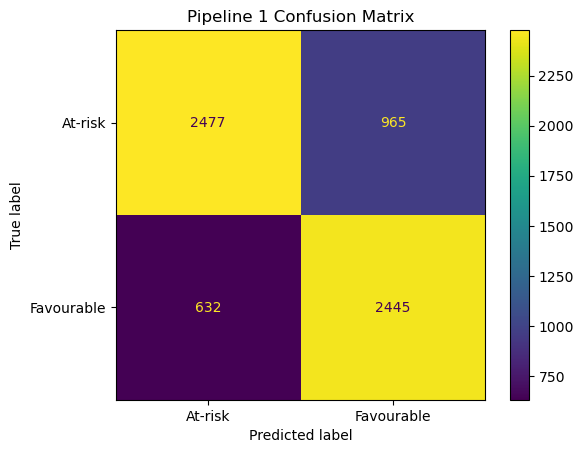

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred_p1 = pipeline_1.predict(X_test)
y_proba_p1 = pipeline_1.predict_proba(X_test)[:, 1]

# Classification report
print(classification_report(y_test, y_pred_p1))

# AUC
auc_p1 = roc_auc_score(y_test, y_proba_p1)
print("AUC:", auc_p1)

# Confusion matrix
cm_p1 = confusion_matrix(y_test, y_pred_p1)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_p1,
    display_labels=["At-risk", "Favourable"]
)

disp.plot()
plt.title("Pipeline 1 Confusion Matrix")
plt.show()

## 10. Threshold Tuning

Adjust the decision threshold to improve detection of at-risk students.

In [41]:
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_thresh = (y_proba_p1 >= t).astype(int)
    
    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()
    
    recall_at_risk = tn / (tn + fp)
    recall_fav = tp / (tp + fn)
    
    results.append((t, recall_at_risk, recall_fav))

for r in results:
    print(f"Threshold={r[0]:.2f} | At-risk recall={r[1]:.2f} | Fav recall={r[2]:.2f}")

Threshold=0.10 | At-risk recall=0.37 | Fav recall=0.99
Threshold=0.15 | At-risk recall=0.39 | Fav recall=0.99
Threshold=0.20 | At-risk recall=0.42 | Fav recall=0.98
Threshold=0.25 | At-risk recall=0.47 | Fav recall=0.97
Threshold=0.30 | At-risk recall=0.51 | Fav recall=0.95
Threshold=0.35 | At-risk recall=0.57 | Fav recall=0.92
Threshold=0.40 | At-risk recall=0.62 | Fav recall=0.89
Threshold=0.45 | At-risk recall=0.67 | Fav recall=0.85
Threshold=0.50 | At-risk recall=0.72 | Fav recall=0.79
Threshold=0.55 | At-risk recall=0.77 | Fav recall=0.74
Threshold=0.60 | At-risk recall=0.82 | Fav recall=0.66
Threshold=0.65 | At-risk recall=0.87 | Fav recall=0.57
Threshold=0.70 | At-risk recall=0.90 | Fav recall=0.47
Threshold=0.75 | At-risk recall=0.94 | Fav recall=0.35
Threshold=0.80 | At-risk recall=0.96 | Fav recall=0.26
Threshold=0.85 | At-risk recall=0.98 | Fav recall=0.16


In [42]:
threshold = 0.60

y_pred_tuned = (y_proba_p1 >= threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification report (tuned threshold):")
print(classification_report(y_test, y_pred_tuned))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("Confusion matrix:\n", cm_tuned)

Classification report (tuned threshold):
              precision    recall  f1-score   support

           0       0.73      0.82      0.77      3442
           1       0.77      0.66      0.71      3077

    accuracy                           0.75      6519
   macro avg       0.75      0.74      0.74      6519
weighted avg       0.75      0.75      0.75      6519

Confusion matrix:
 [[2829  613]
 [1036 2041]]


## 11. Pipeline 2 – Advanced Model

This pipeline changes the model component by using a Gradient Boosting classifier. This is the self-learned improvement beyond the baseline Logistic Regression pipeline.

In [44]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing for Pipeline 2
# Tree-based boosting does not need scaling.
preprocessor_p2 = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# Pipeline 2: Gradient Boosting
pipeline_2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_p2),
        ("model", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

pipeline_2.fit(X_train, y_train)

print("Pipeline 2 trained successfully")

Pipeline 2 trained successfully


In [45]:
train_score_p2 = pipeline_2.score(X_train, y_train)
test_score_p2 = pipeline_2.score(X_test, y_test)

print("Pipeline 2 train accuracy:", train_score_p2)
print("Pipeline 2 test accuracy:", test_score_p2)

Pipeline 2 train accuracy: 0.7897138912326456
Pipeline 2 test accuracy: 0.7708237459733088


              precision    recall  f1-score   support

           0       0.82      0.73      0.77      3442
           1       0.73      0.82      0.77      3077

    accuracy                           0.77      6519
   macro avg       0.77      0.77      0.77      6519
weighted avg       0.78      0.77      0.77      6519

Pipeline 2 AUC: 0.8504852783968024


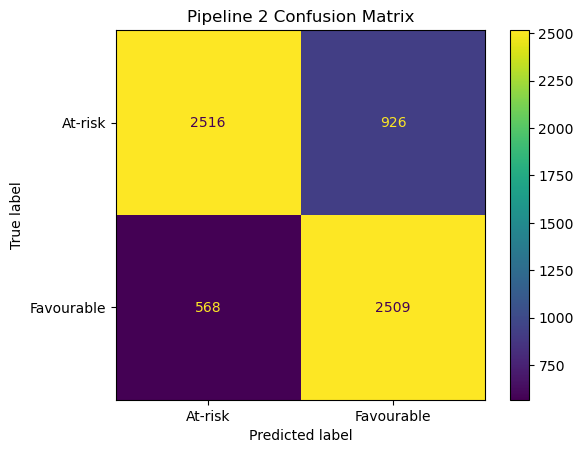

In [46]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_p2 = pipeline_2.predict(X_test)
y_proba_p2 = pipeline_2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_p2))

auc_p2 = roc_auc_score(y_test, y_proba_p2)
print("Pipeline 2 AUC:", auc_p2)

cm_p2 = confusion_matrix(y_test, y_pred_p2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_p2,
    display_labels=["At-risk", "Favourable"]
)

disp.plot()
plt.title("Pipeline 2 Confusion Matrix")
plt.show()

## 12. Model Comparison

Compare the performance of both pipelines in terms of accuracy, recall, and AUC.


In [47]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "AUC"],
    "Pipeline 1": [test_score_p1, auc_p1],
    "Pipeline 2": [test_score_p2, auc_p2]
})

comparison

,Metric,Pipeline 1,Pipeline 2
0,Accuracy,0.755024,0.770824
1,AUC,0.841167,0.850485


In [48]:
from sklearn.metrics import recall_score

recall_p1 = recall_score(y_test, y_pred_p1)
recall_p2 = recall_score(y_test, y_pred_p2)

print("Recall P1:", recall_p1)
print("Recall P2:", recall_p2)

Recall P1: 0.7946051348716282
Recall P2: 0.8154046148846279


## 13. Summary of Results

Two pipelines were developed to predict student outcomes using only week-4 data.

**Pipeline 1 (Logistic Regression):**
- Accuracy: ~0.755
- AUC: ~0.84
- At-risk recall (default threshold): ~0.72
- After threshold tuning (0.60): at-risk recall improved to ~0.82 with a small drop in overall accuracy.

**Pipeline 2 (Gradient Boosting):**
- Accuracy: ~0.771
- AUC: ~0.85
- Better balance between classes (recall ~0.73 for at-risk and ~0.82 for favourable).
- Reduced missed at-risk students compared to Pipeline 1.

**Conclusion:**
- Pipeline 2 outperforms Pipeline 1 in both accuracy and AUC.
- Threshold tuning on Pipeline 1 significantly improves early detection of at-risk students.
- Gradient Boosting is better suited for capturing complex patterns in student behaviour data.

Overall, the models demonstrate that early engagement and assessment activity can effectively predict student outcomes.

## ROC Curve Comparison

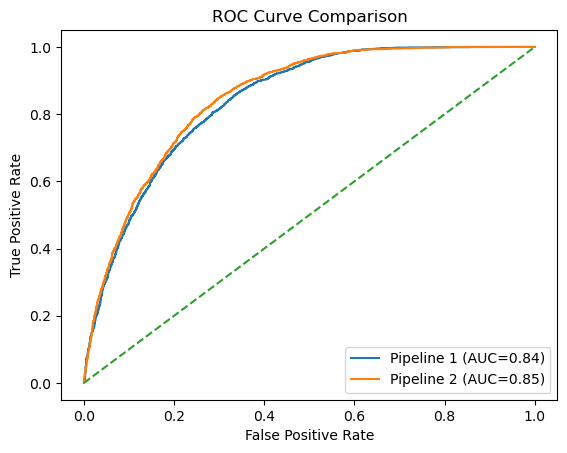

In [49]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr1, tpr1, _ = roc_curve(y_test, y_proba_p1)
fpr2, tpr2, _ = roc_curve(y_test, y_proba_p2)

plt.figure()
plt.plot(fpr1, tpr1, label=f"Pipeline 1 (AUC={auc_p1:.2f})")
plt.plot(fpr2, tpr2, label=f"Pipeline 2 (AUC={auc_p2:.2f})")

plt.plot([0,1], [0,1], linestyle="--")  # random model

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Feature Importance (Pipeline 2)

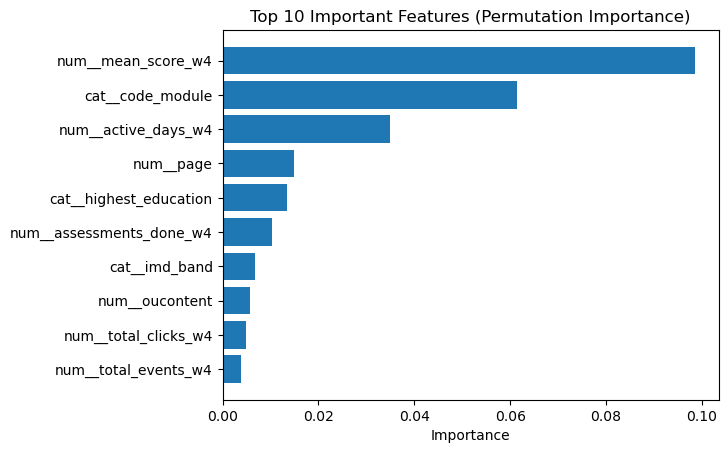

In [51]:
from sklearn.inspection import permutation_importance

# Compute permutation importance
perm_importance = permutation_importance(
    pipeline_2,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Get feature names
feature_names = pipeline_2.named_steps["preprocessor"].get_feature_names_out()

# Create DataFrame
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": perm_importance.importances_mean
}).sort_values(by="importance", ascending=False)

# Top 10
top10 = feat_imp.head(10)

# Plot
import matplotlib.pyplot as plt

plt.figure()
plt.barh(top10["feature"], top10["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (Permutation Importance)")
plt.xlabel("Importance")
plt.show()

In [53]:
plt.savefig("ROC Curve Comparison.png")

<Figure size 640x480 with 0 Axes>

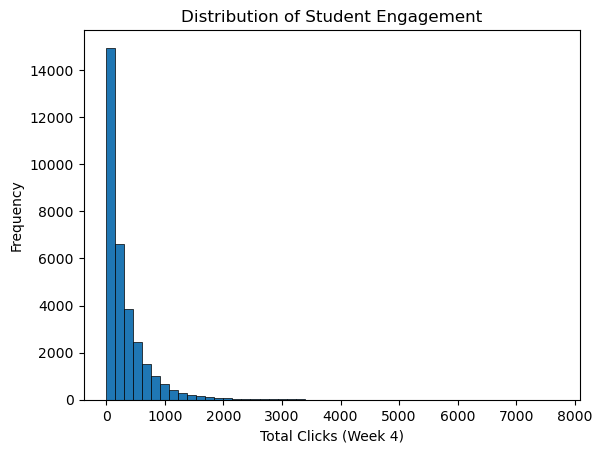

In [55]:
import matplotlib.pyplot as plt

plt.hist(
    df["total_clicks_w4"],
    bins=50,
    edgecolor="black",   # adds borders
    linewidth=0.5        # thickness of borders
)

plt.xlabel("Total Clicks (Week 4)")
plt.ylabel("Frequency")
plt.title("Distribution of Student Engagement")

plt.savefig("clicks_distribution.png")
plt.show()

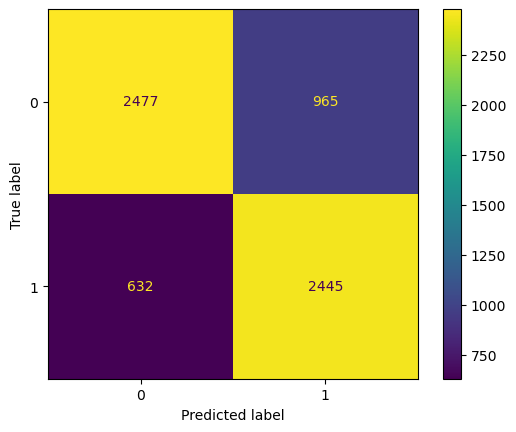

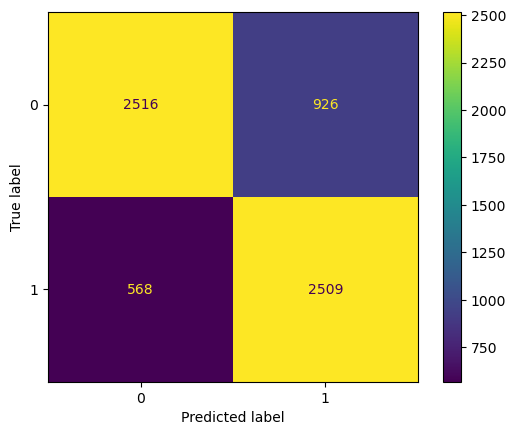

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Pipeline 1
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_p1)
plt.savefig("cm_p1.png")

# Pipeline 2
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_p2)
plt.savefig("cm_p2.png")

In [59]:
from sklearn.metrics import log_loss

logloss_p1 = log_loss(y_test, y_proba_p1)
logloss_p2 = log_loss(y_test, y_proba_p2)

print("Log Loss P1:", logloss_p1)
print("Log Loss P2:", logloss_p2)

Log Loss P1: 0.4779060735783406
Log Loss P2: 0.4675882937564646
